In [1]:
# EXP7 T0 CELL 1 - IMPORTS, SEED AND DATA. Loads MNIST, takes a fixed seeded subset of 10,000 train and 2,000 test images,
# scales pixels from [0,255] to [0,1] and keeps the (N,28,28,1) shape so the same arrays feed the FC, conv and variational models.
import os, time, random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from skimage.metrics import structural_similarity as ssim_fn

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
os.makedirs("figs", exist_ok=True)

(x_tr_full, y_tr_full), (x_te_full, y_te_full) = keras.datasets.mnist.load_data()
rng = np.random.default_rng(SEED)
tr_idx = rng.permutation(len(x_tr_full))[:10000]
te_idx = rng.permutation(len(x_te_full))[:2000]

x_train = (x_tr_full[tr_idx].astype("float32") / 255.0)[..., None]
y_train = y_tr_full[tr_idx]
x_test  = (x_te_full[te_idx].astype("float32") / 255.0)[..., None]
y_test  = y_te_full[te_idx]

print("x_train", x_train.shape, "| x_test", x_test.shape,
      "| range [%.1f, %.1f]" % (x_train.min(), x_train.max()))
print("train digit counts:", np.bincount(y_train))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train (10000, 28, 28, 1) | x_test (2000, 28, 28, 1) | range [0.0, 1.0]
train digit counts: [1008 1142  978 1061  973  878  973 1033  973  981]


In [2]:
# EXP7 T0 CELL 0 - GPU CHECK. Lists the GPUs TensorFlow can see and runs a tiny op to confirm it is placed on the GPU.
# An empty list means the runtime is CPU-only. Run this once at the top, after the imports cell.
print("TF version:", tf.__version__)
gpus = tf.config.list_physical_devices("GPU")
print("GPUs visible to TensorFlow:", gpus)
if gpus:
    with tf.device("/GPU:0"):
        a = tf.random.normal((2000, 2000)); b = tf.matmul(a, a)
    print("matmul ran on:", b.device)
else:
    print("No GPU found. Runtime > Change runtime type > T4 GPU, then Runtime > Restart session and run all cells again.")

TF version: 2.20.0
GPUs visible to TensorFlow: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
matmul ran on: /job:localhost/replica:0/task:0/device:GPU:0


In [3]:
# EXP7 T0 CELL 2 - HELPERS. evaluate_recon returns test MSE, MAE and mean SSIM (skimage, data_range=1) between originals and
# reconstructions; per_image_mse gives e_i for the error histogram later; RESULTS collects every model's numbers for the final table.
def evaluate_recon(x, xhat):
    x = x.reshape(-1, 28, 28, 1); xhat = xhat.reshape(-1, 28, 28, 1)
    mse = float(np.mean((x - xhat) ** 2))
    mae = float(np.mean(np.abs(x - xhat)))
    ssim = float(np.mean([ssim_fn(a[..., 0], b[..., 0], data_range=1.0) for a, b in zip(x, xhat)]))
    return {"MSE": mse, "MAE": mae, "SSIM": ssim}

def per_image_mse(x, xhat):
    x = x.reshape(-1, 28, 28, 1); xhat = xhat.reshape(-1, 28, 28, 1)
    return np.mean((x - xhat) ** 2, axis=(1, 2, 3))

RESULTS = {}   # model name -> dict(MSE, MAE, SSIM, Params, Time)
print("helpers ready")

helpers ready


In [4]:
# EXP7 T0 CELL 3 - PLOT STYLE AND SAVE HELPER. Sets a Times-like serif font (STIX fallback, bundled with matplotlib) for all text and
# math labels, embeds fonts as TrueType (Type 42) so EPS/PDF text stays editable, and defines save_fig(), which writes EPS, PDF and PNG
# for every figure in one call so you can choose the format your report needs.
import matplotlib as mpl
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "STIXGeneral", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "axes.unicode_minus": False,
    "ps.fonttype": 42,
    "pdf.fonttype": 42,
    "font.size": 11,
})

def save_fig(name):
    plt.savefig(f"figs/{name}.eps", format="eps", bbox_inches="tight")
    plt.savefig(f"figs/{name}.png", dpi=300, bbox_inches="tight")
print("style set; figures will be saved as figs/<name>.eps / .pdf / .png")

style set; figures will be saved as figs/<name>.eps / .pdf / .png


In [5]:
# EXP7 T1 CELL 1 - FULLY CONNECTED AUTOENCODER. Architecture 784-128-32-dz-32-128-784 with ReLU hidden layers and a sigmoid output.
# Flatten/Reshape sit inside the model so it takes and returns (28,28,1) images, which keeps metrics and plots identical across models.
# build_fc_ae takes latent_dim so the same function is reused for the latent-dimension study (dz = 2, 8, 16, 32).
def build_fc_ae(latent_dim=16, name="fc_ae"):
    inp = keras.Input((28, 28, 1))
    h = layers.Flatten()(inp)
    h = layers.Dense(128, activation="relu")(h)
    h = layers.Dense(32, activation="relu")(h)
    z = layers.Dense(latent_dim, name="latent")(h)
    h = layers.Dense(32, activation="relu")(z)
    h = layers.Dense(128, activation="relu")(h)
    h = layers.Dense(784, activation="sigmoid")(h)
    out = layers.Reshape((28, 28, 1))(h)
    ae = keras.Model(inp, out, name=name)
    enc = keras.Model(inp, z, name=name + "_encoder")
    ae.compile(optimizer=keras.optimizers.Adam(1e-3), loss="binary_crossentropy", metrics=["mse"])
    return ae, enc

fc_ae, fc_enc = build_fc_ae(16)
fc_ae.summary()

Model: "fc_ae"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 784)            │       101,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 211,040 (824.38 KB)

 Trainable params: 211,040 (824.38 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# EXP7 T1 CELL 2 - TRAIN THE FC AUTOENCODER. 20 epochs, batch 128, Adam 1e-3, BCE loss. The input is also the target.
# 10% of the training subset is held out for validation (test set is never seen). Wall-clock training time is stored for the final table.
tf.random.set_seed(SEED)
t0 = time.perf_counter()
fc_hist = fc_ae.fit(x_train, x_train, epochs=20, batch_size=128,
                    validation_split=0.1, shuffle=True, verbose=2)
fc_time = time.perf_counter() - t0
print(f"training time: {fc_time:.1f}s")

Epoch 1/20
71/71 - 6s - 85ms/step - loss: 0.3523 - mse: 0.0962 - val_loss: 0.2585 - val_mse: 0.0652
Epoch 2/20
71/71 - 0s - 6ms/step - loss: 0.2317 - mse: 0.0564 - val_loss: 0.2039 - val_mse: 0.0472
Epoch 3/20
71/71 - 1s - 7ms/step - loss: 0.1929 - mse: 0.0437 - val_loss: 0.1800 - val_mse: 0.0393
Epoch 4/20
71/71 - 0s - 4ms/step - loss: 0.1742 - mse: 0.0374 - val_loss: 0.1684 - val_mse: 0.0355
Epoch 5/20
71/71 - 0s - 4ms/step - loss: 0.1642 - mse: 0.0341 - val_loss: 0.1602 - val_mse: 0.0327
Epoch 6/20
71/71 - 0s - 4ms/step - loss: 0.1566 - mse: 0.0315 - val_loss: 0.1534 - val_mse: 0.0303
Epoch 7/20
71/71 - 0s - 4ms/step - loss: 0.1505 - mse: 0.0294 - val_loss: 0.1480 - val_mse: 0.0285
Epoch 8/20
71/71 - 0s - 4ms/step - loss: 0.1455 - mse: 0.0277 - val_loss: 0.1434 - val_mse: 0.0269
Epoch 9/20
71/71 - 0s - 4ms/step - loss: 0.1416 - mse: 0.0263 - val_loss: 0.1402 - val_mse: 0.0258
Epoch 10/20
71/71 - 0s - 4ms/step - loss: 0.1386 - mse: 0.0254 - val_loss: 0.1377 - val_mse: 0.0250
Epoch 11

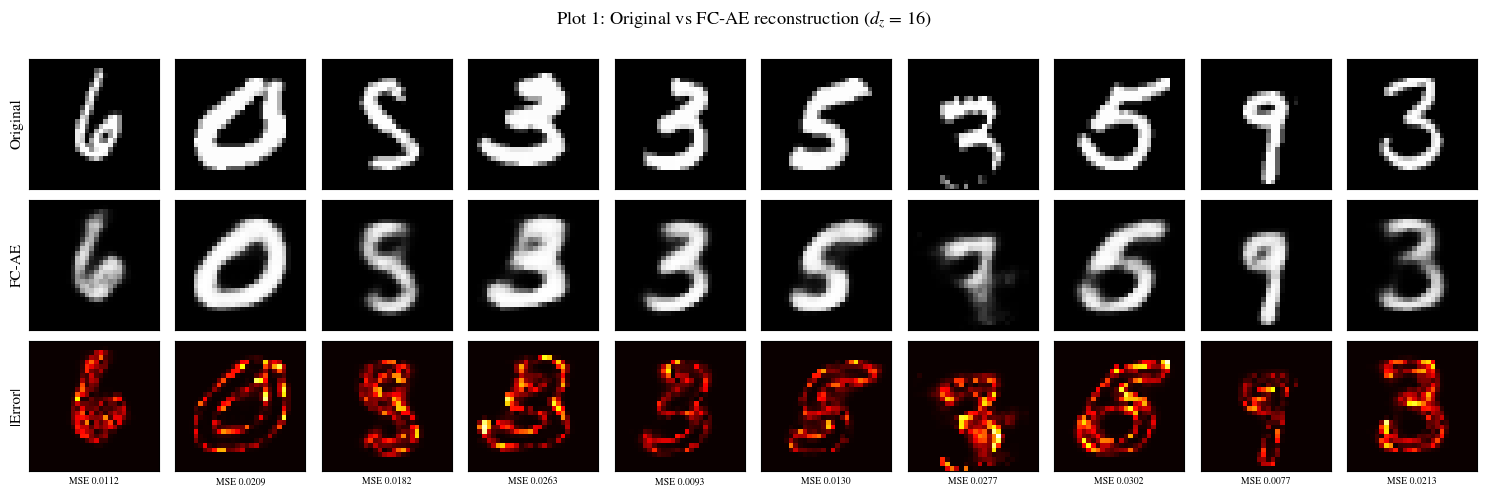

In [7]:
# EXP7 T1 CELL 3 - PLOT 1: ORIGINAL vs RECONSTRUCTED vs ERROR. Shows the first 10 test images with their reconstruction and the
# absolute pixel error map (brighter = larger error). Saved as EPS, PDF and PNG through save_fig.
fc_recon = fc_ae.predict(x_test, verbose=0)

n = 10
fig, axes = plt.subplots(3, n, figsize=(1.5 * n, 5))
for i in range(n):
    axes[0, i].imshow(x_test[i, ..., 0], cmap="gray", vmin=0, vmax=1)
    axes[1, i].imshow(fc_recon[i, ..., 0], cmap="gray", vmin=0, vmax=1)
    axes[2, i].imshow(np.abs(x_test[i, ..., 0] - fc_recon[i, ..., 0]), cmap="hot", vmin=0, vmax=1)
    axes[2, i].set_xlabel(f"MSE {np.mean((x_test[i]-fc_recon[i])**2):.4f}", fontsize=7)
    for r in range(3):
        axes[r, i].set_xticks([]); axes[r, i].set_yticks([])
axes[0, 0].set_ylabel("Original"); axes[1, 0].set_ylabel("FC-AE"); axes[2, 0].set_ylabel("|Error|")
plt.suptitle("Plot 1: Original vs FC-AE reconstruction ($d_z$ = 16)")
plt.tight_layout(); save_fig("plot1_fc_recon"); plt.show()

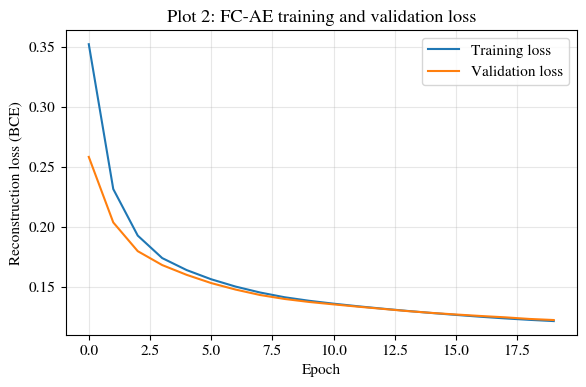

final train loss 0.1217 | final val loss 0.1226 | gap 0.0009


In [8]:
# EXP7 T1 CELL 4 - PLOT 2: TRAINING vs VALIDATION RECONSTRUCTION LOSS. The y-axis is binary cross-entropy (the training loss).
# Look for: does the curve flatten (convergence) and does the validation curve rise or separate from training (overfitting)?
plt.figure(figsize=(6, 4))
plt.plot(fc_hist.history["loss"], label="Training loss")
plt.plot(fc_hist.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch"); plt.ylabel("Reconstruction loss (BCE)")
plt.title("Plot 2: FC-AE training and validation loss")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
save_fig("plot2_fc_loss"); plt.show()
print("final train loss %.4f | final val loss %.4f | gap %.4f" % (
    fc_hist.history["loss"][-1], fc_hist.history["val_loss"][-1],
    fc_hist.history["val_loss"][-1] - fc_hist.history["loss"][-1]))

In [9]:
# EXP7 T1 CELL 5 - TEST-SET METRICS FOR THE FC AUTOENCODER. MSE, MAE and mean SSIM on the 2,000 unseen test images, plus parameter
# count and training time, stored in RESULTS for the FC vs CAE comparison and the consolidated table.
m = evaluate_recon(x_test, fc_recon)
RESULTS["FC Autoencoder"] = {**m, "Params": fc_ae.count_params(), "Time": fc_time}

print(f"{'Metric':<10}{'Value':>10}")
print(f"{'Test MSE':<10}{m['MSE']:>10.5f}")
print(f"{'Test MAE':<10}{m['MAE']:>10.5f}")
print(f"{'Mean SSIM':<10}{m['SSIM']:>10.4f}")
print("Params:", f"{fc_ae.count_params():,}", "| Time: %.1fs" % fc_time)

Metric         Value
Test MSE     0.01992
Test MAE     0.05442
Mean SSIM     0.7749
Params: 211,040 | Time: 12.0s


In [10]:
# EXP7 T1 CELL 6 - LATENT-DIMENSION STUDY (dz = 2, 8, 16, 32). Retrains the same FC architecture with only the bottleneck width changed,
# same data, epochs, batch size and seed, and records test MSE, SSIM and parameter count for each. Feeds the table and Plot 10.
LATENT_DIMS = [2, 8, 16, 32]
dz_results = {}
for dz in LATENT_DIMS:
    tf.random.set_seed(SEED)
    ae, _ = build_fc_ae(dz, name=f"fc_ae_dz{dz}")
    ae.fit(x_train, x_train, epochs=20, batch_size=128, validation_split=0.1, shuffle=True, verbose=0)
    rec = ae.predict(x_test, verbose=0)
    mm = evaluate_recon(x_test, rec)
    dz_results[dz] = {**mm, "Params": ae.count_params(), "recon": rec}
    print(f"dz={dz:>2} | MSE {mm['MSE']:.5f} | SSIM {mm['SSIM']:.4f} | params {ae.count_params():,}")

print(f"\n{'Latent Dim':<12}{'MSE':>10}{'SSIM':>10}{'Params':>12}")
for dz in LATENT_DIMS:
    r = dz_results[dz]
    print(f"{dz:<12}{r['MSE']:>10.5f}{r['SSIM']:>10.4f}{r['Params']:>12,}")

dz= 2 | MSE 0.04718 | SSIM 0.4729 | params 210,130
dz= 8 | MSE 0.02595 | SSIM 0.7107 | params 210,520
dz=16 | MSE 0.02025 | SSIM 0.7712 | params 211,040
dz=32 | MSE 0.01919 | SSIM 0.7814 | params 212,080

Latent Dim         MSE      SSIM      Params
2              0.04718    0.4729     210,130
8              0.02595    0.7107     210,520
16             0.02025    0.7712     211,040
32             0.01919    0.7814     212,080


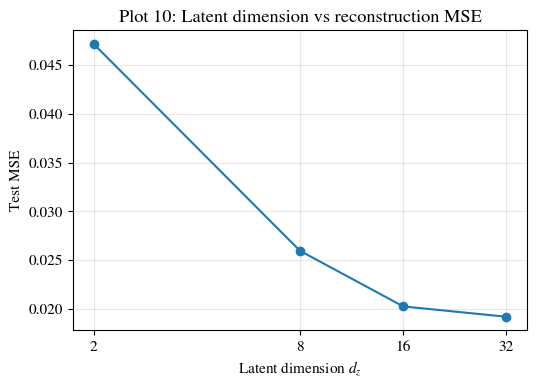

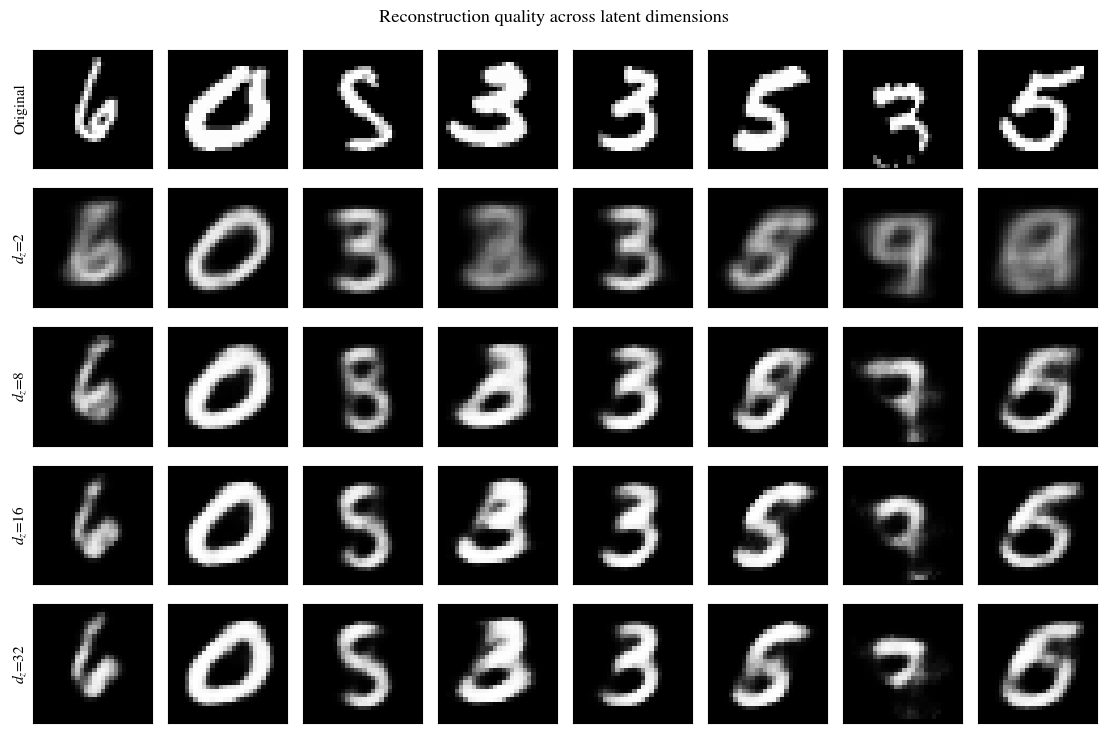

In [11]:
# EXP7 T1 CELL 7 - PLOT 10: LATENT DIMENSION vs RECONSTRUCTION MSE, plus a visual row per dz for the same 8 test digits.
# Shows the compression vs quality trade-off: small dz forces heavy compression, and returns diminish as dz grows.
plt.figure(figsize=(5.5, 4))
plt.plot(LATENT_DIMS, [dz_results[d]["MSE"] for d in LATENT_DIMS], "o-")
plt.xscale("log", base=2); plt.xticks(LATENT_DIMS, LATENT_DIMS)
plt.xlabel("Latent dimension $d_z$"); plt.ylabel("Test MSE")
plt.title("Plot 10: Latent dimension vs reconstruction MSE")
plt.grid(alpha=0.3); plt.tight_layout(); save_fig("plot10_dz_mse"); plt.show()

n = 8
fig, axes = plt.subplots(len(LATENT_DIMS) + 1, n, figsize=(1.4 * n, 1.5 * (len(LATENT_DIMS) + 1)))
for i in range(n):
    axes[0, i].imshow(x_test[i, ..., 0], cmap="gray", vmin=0, vmax=1)
    for r, dz in enumerate(LATENT_DIMS, start=1):
        axes[r, i].imshow(dz_results[dz]["recon"][i, ..., 0], cmap="gray", vmin=0, vmax=1)
    for r in range(len(LATENT_DIMS) + 1):
        axes[r, i].set_xticks([]); axes[r, i].set_yticks([])
axes[0, 0].set_ylabel("Original")
for r, dz in enumerate(LATENT_DIMS, start=1):
    axes[r, 0].set_ylabel(f"$d_z$={dz}")
plt.suptitle("Reconstruction quality across latent dimensions")
plt.tight_layout();
save_fig("dz_visual_grid"); plt.show()

In [12]:
# EXP7 T2 CELL 1 - CONVOLUTIONAL AUTOENCODER. Follows the manual's layout: Conv32-Pool-Conv64-Pool (encoder, latent map 7x7x64), then
# Conv64-Up-Conv32-Up-Conv1 sigmoid (decoder). build_cae is a function so the denoising CAE in T3 reuses the identical architecture.
def build_cae(name="cae"):
    inp = keras.Input((28, 28, 1))
    h = layers.Conv2D(32, 3, activation="relu", padding="same")(inp)
    h = layers.MaxPooling2D(2, padding="same")(h)                       # 14x14x32
    h = layers.Conv2D(64, 3, activation="relu", padding="same")(h)
    z = layers.MaxPooling2D(2, padding="same", name="latent_map")(h)    # 7x7x64 latent feature map
    h = layers.Conv2D(64, 3, activation="relu", padding="same")(z)
    h = layers.UpSampling2D(2)(h)                                       # 14x14x64
    h = layers.Conv2D(32, 3, activation="relu", padding="same")(h)
    h = layers.UpSampling2D(2)(h)                                       # 28x28x32
    out = layers.Conv2D(1, 3, activation="sigmoid", padding="same")(h)
    ae = keras.Model(inp, out, name=name)
    ae.compile(optimizer=keras.optimizers.Adam(1e-3), loss="binary_crossentropy", metrics=["mse"])
    return ae

cae = build_cae()
cae.summary()
print("latent feature map size:", 7 * 7 * 64, "values per image (input has 784)")

Model: "cae"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_map (MaxPooling2D)       │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

latent feature map size: 3136 values per image (input has 784)


In [13]:
# EXP7 T2 CELL 2 - TRAIN THE CAE. Identical protocol to the FC-AE (20 epochs, batch 128, Adam 1e-3, BCE, 10% validation split,
# same seed) so the only difference between the two models is the architecture. Training time is stored for the consolidated table.
tf.random.set_seed(SEED)
t0 = time.perf_counter()
cae_hist = cae.fit(x_train, x_train, epochs=20, batch_size=128,
                   validation_split=0.1, shuffle=True, verbose=2)
cae_time = time.perf_counter() - t0
print(f"training time: {cae_time:.1f}s")

Epoch 1/20
71/71 - 8s - 116ms/step - loss: 0.2601 - mse: 0.0650 - val_loss: 0.1122 - val_mse: 0.0168
Epoch 2/20
71/71 - 1s - 9ms/step - loss: 0.0954 - mse: 0.0111 - val_loss: 0.0864 - val_mse: 0.0082
Epoch 3/20
71/71 - 1s - 9ms/step - loss: 0.0835 - mse: 0.0072 - val_loss: 0.0804 - val_mse: 0.0063
Epoch 4/20
71/71 - 1s - 17ms/step - loss: 0.0795 - mse: 0.0060 - val_loss: 0.0777 - val_mse: 0.0054
Epoch 5/20
71/71 - 1s - 8ms/step - loss: 0.0772 - mse: 0.0053 - val_loss: 0.0762 - val_mse: 0.0050
Epoch 6/20
71/71 - 1s - 8ms/step - loss: 0.0756 - mse: 0.0048 - val_loss: 0.0745 - val_mse: 0.0045
Epoch 7/20
71/71 - 1s - 7ms/step - loss: 0.0744 - mse: 0.0044 - val_loss: 0.0734 - val_mse: 0.0041
Epoch 8/20
71/71 - 1s - 8ms/step - loss: 0.0734 - mse: 0.0041 - val_loss: 0.0726 - val_mse: 0.0039
Epoch 9/20
71/71 - 1s - 8ms/step - loss: 0.0727 - mse: 0.0039 - val_loss: 0.0722 - val_mse: 0.0037
Epoch 10/20
71/71 - 1s - 8ms/step - loss: 0.0721 - mse: 0.0037 - val_loss: 0.0715 - val_mse: 0.0035
Epoch 

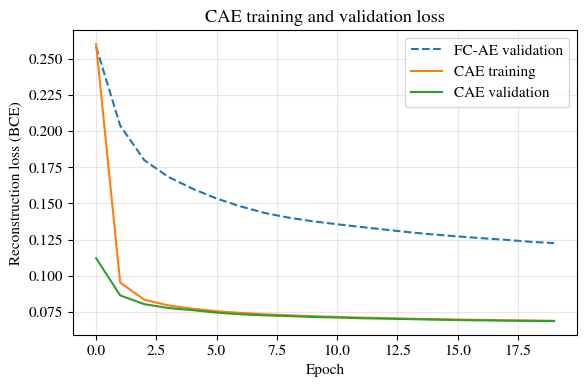

CAE final train 0.0689 | final val 0.0687


In [14]:
# EXP7 T2 CELL 3 - CAE TRAINING vs VALIDATION LOSS. Not one of the ten required plots, but it lets you state whether the CAE converges
# and overfits, and compare its curve with the FC-AE curve on the same axes.
plt.figure(figsize=(6, 4))
plt.plot(fc_hist.history["val_loss"], "--", label="FC-AE validation")
plt.plot(cae_hist.history["loss"], label="CAE training")
plt.plot(cae_hist.history["val_loss"], label="CAE validation")
plt.xlabel("Epoch"); plt.ylabel("Reconstruction loss (BCE)")
plt.title("CAE training and validation loss")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
save_fig("cae_loss"); plt.show()
print("CAE final train %.4f | final val %.4f" % (cae_hist.history["loss"][-1], cae_hist.history["val_loss"][-1]))

In [15]:
# EXP7 T2 CELL 4 - TEST METRICS AND FC vs CAE TABLE. Evaluates the CAE on the 2,000 unseen test images, stores it in RESULTS, and prints
# the comparison table required by the manual (MSE, MAE, SSIM, Parameters) with FC-AE and CAE side by side.
cae_recon = cae.predict(x_test, verbose=0)
m = evaluate_recon(x_test, cae_recon)
RESULTS["Conv. Autoencoder"] = {**m, "Params": cae.count_params(), "Time": cae_time}

print(f"{'Model':<20}{'MSE':>10}{'MAE':>10}{'SSIM':>10}{'Params':>12}{'Time (s)':>10}")
for k in ["FC Autoencoder", "Conv. Autoencoder"]:
    r = RESULTS[k]
    print(f"{k:<20}{r['MSE']:>10.5f}{r['MAE']:>10.5f}{r['SSIM']:>10.4f}{r['Params']:>12,}{r['Time']:>10.1f}")

fc_r, cae_r = RESULTS["FC Autoencoder"], RESULTS["Conv. Autoencoder"]
print(f"\nCAE MSE is {100*(1 - cae_r['MSE']/fc_r['MSE']):.1f}% lower than FC-AE | "
      f"SSIM difference {cae_r['SSIM'] - fc_r['SSIM']:+.4f}")

Model                      MSE       MAE      SSIM      Params  Time (s)
FC Autoencoder         0.01992   0.05442    0.7749     211,040      12.0
Conv. Autoencoder      0.00264   0.01554    0.9725      74,497      20.7

CAE MSE is 86.7% lower than FC-AE | SSIM difference +0.1976


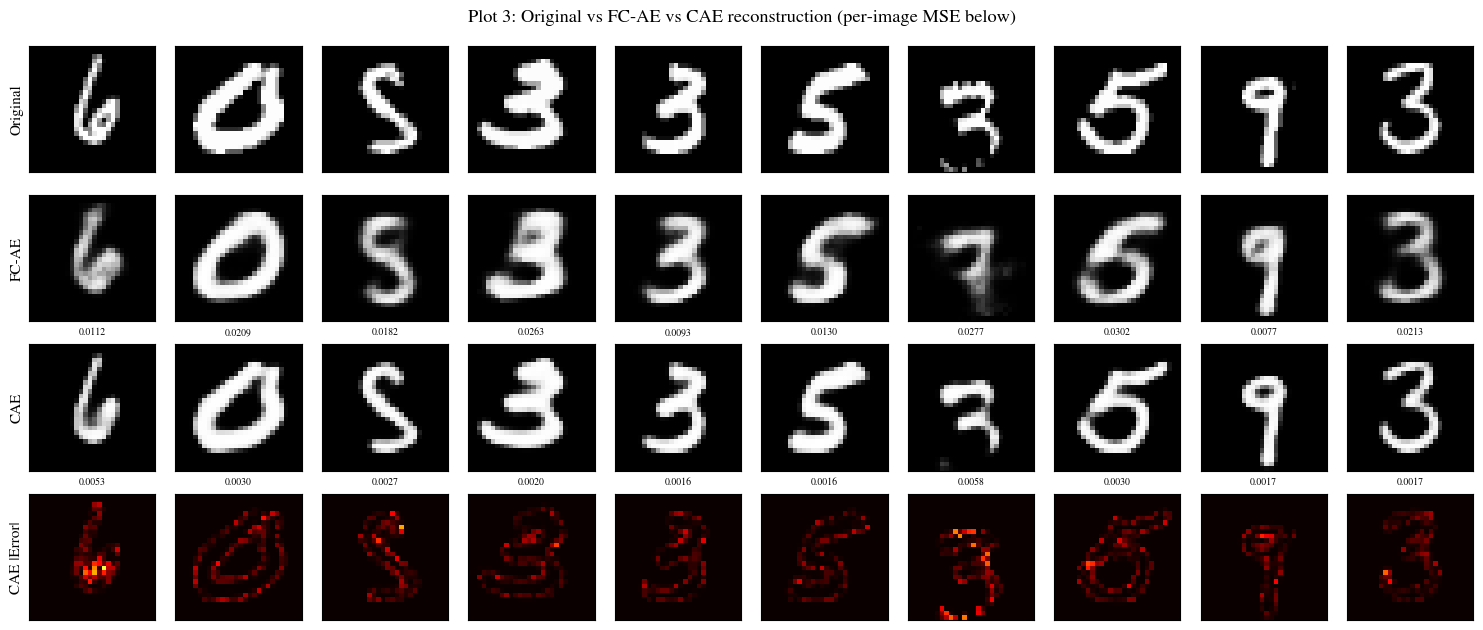

In [16]:
# EXP7 T2 CELL 5 - PLOT 3: RECONSTRUCTION COMPARISON. Rows: original, FC-AE reconstruction, CAE reconstruction, and the CAE absolute
# error map, for the same first 10 test images used in Plot 1. Per-image MSE is printed under each reconstruction.
n = 10
fig, axes = plt.subplots(4, n, figsize=(1.5 * n, 6.4))
for i in range(n):
    axes[0, i].imshow(x_test[i, ..., 0], cmap="gray", vmin=0, vmax=1)
    axes[1, i].imshow(fc_recon[i, ..., 0], cmap="gray", vmin=0, vmax=1)
    axes[2, i].imshow(cae_recon[i, ..., 0], cmap="gray", vmin=0, vmax=1)
    axes[3, i].imshow(np.abs(x_test[i, ..., 0] - cae_recon[i, ..., 0]), cmap="hot", vmin=0, vmax=1)
    axes[1, i].set_xlabel(f"{np.mean((x_test[i]-fc_recon[i])**2):.4f}", fontsize=7)
    axes[2, i].set_xlabel(f"{np.mean((x_test[i]-cae_recon[i])**2):.4f}", fontsize=7)
    for r in range(4):
        axes[r, i].set_xticks([]); axes[r, i].set_yticks([])
axes[0, 0].set_ylabel("Original"); axes[1, 0].set_ylabel("FC-AE")
axes[2, 0].set_ylabel("CAE"); axes[3, 0].set_ylabel("CAE |Error|")
plt.suptitle("Plot 3: Original vs FC-AE vs CAE reconstruction (per-image MSE below)")
plt.tight_layout(); save_fig("plot3_fc_vs_cae"); plt.show()

In [17]:
# EXP7 T3 CELL 1 - NOISE FUNCTIONS AND NOISY DATASETS. Defines Gaussian noise (sigma = 0.1, 0.2, 0.3, clipped to [0,1]) and
# salt-and-pepper noise (p = 0.05, 0.10, 0.20, half the corrupted pixels set to 0 and half to 1), then builds a fixed noisy
# copy of the train and test sets for every level using separate seeded generators. The clean images stay untouched
# because they remain the training TARGET - this is the defining feature of a denoising autoencoder.
GAUSS_SIGMAS = [0.1, 0.2, 0.3]
SP_PROBS     = [0.05, 0.10, 0.20]

def add_gaussian_noise(x, sigma, rng):
    return np.clip(x + rng.normal(0.0, sigma, x.shape), 0.0, 1.0).astype("float32")

def add_salt_pepper_noise(x, p, rng):
    out = x.copy()
    u = rng.random(x.shape)
    out[u < p / 2] = 0.0                       # pepper
    out[(u >= p / 2) & (u < p)] = 1.0          # salt
    return out.astype("float32")

noisy_train, noisy_test = {}, {}
for i, s in enumerate(GAUSS_SIGMAS):
    noisy_train[("gaussian", s)] = add_gaussian_noise(x_train, s, np.random.default_rng(SEED + i))
    noisy_test[("gaussian", s)]  = add_gaussian_noise(x_test,  s, np.random.default_rng(SEED + 1000 + i))
for i, p in enumerate(SP_PROBS):
    noisy_train[("sp", p)] = add_salt_pepper_noise(x_train, p, np.random.default_rng(SEED + 10 + i))
    noisy_test[("sp", p)]  = add_salt_pepper_noise(x_test,  p, np.random.default_rng(SEED + 1010 + i))

for key in noisy_test:
    print(f"{key[0]:>8} level={key[1]:<5} | train {noisy_train[key].shape} | test {noisy_test[key].shape} "
          f"| range [{noisy_test[key].min():.2f}, {noisy_test[key].max():.2f}]")

gaussian level=0.1   | train (10000, 28, 28, 1) | test (2000, 28, 28, 1) | range [0.00, 1.00]
gaussian level=0.2   | train (10000, 28, 28, 1) | test (2000, 28, 28, 1) | range [0.00, 1.00]
gaussian level=0.3   | train (10000, 28, 28, 1) | test (2000, 28, 28, 1) | range [0.00, 1.00]
      sp level=0.05  | train (10000, 28, 28, 1) | test (2000, 28, 28, 1) | range [0.00, 1.00]
      sp level=0.1   | train (10000, 28, 28, 1) | test (2000, 28, 28, 1) | range [0.00, 1.00]
      sp level=0.2   | train (10000, 28, 28, 1) | test (2000, 28, 28, 1) | range [0.00, 1.00]


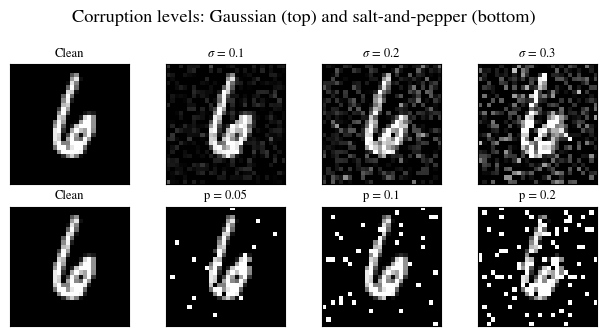

In [18]:
# EXP7 T3 CELL 2 - WHAT THE NOISE LOOKS LIKE. One test digit under every corruption level (top row Gaussian, bottom row salt-and-pepper),
# next to the clean image, so the report can show what each level does to the digit before any denoising is applied.
KEYS = [("gaussian", s) for s in GAUSS_SIGMAS] + [("sp", p) for p in SP_PROBS]
idx = 0
fig, axes = plt.subplots(2, 4, figsize=(6.4, 3.4))
for r, (kind, levels, sym) in enumerate([("gaussian", GAUSS_SIGMAS, r"$\sigma$"), ("sp", SP_PROBS, "p")]):
    axes[r, 0].imshow(x_test[idx, ..., 0], cmap="gray", vmin=0, vmax=1); axes[r, 0].set_title("Clean", fontsize=9)
    for c, lv in enumerate(levels, start=1):
        axes[r, c].imshow(noisy_test[(kind, lv)][idx, ..., 0], cmap="gray", vmin=0, vmax=1)
        axes[r, c].set_title(f"{sym} = {lv}", fontsize=9)
for a in axes.ravel():
    a.set_xticks([]); a.set_yticks([])
plt.suptitle("Corruption levels: Gaussian (top) and salt-and-pepper (bottom)")
plt.tight_layout(); save_fig("noise_examples"); plt.show()

In [19]:
# EXP7 T3 CELL 3 - TRAIN THE DENOISING CAEs. One model per noise setting, same architecture and protocol as the plain CAE (20 epochs,
# batch 128, Adam 1e-3, BCE, 10% validation split). INPUT = noisy image, TARGET = clean image. Validation uses the last 10% of both
# arrays, which are in the same order, so each noisy image is always paired with its own clean image.
dae_models, dae_hist, dae_time = {}, {}, {}
for key in KEYS:
    tf.random.set_seed(SEED)
    mdl = build_cae(name=f"dcae_{key[0]}_{str(key[1]).replace('.', 'p')}")
    t0 = time.perf_counter()
    h = mdl.fit(noisy_train[key], x_train, epochs=20, batch_size=128,
                validation_split=0.1, shuffle=True, verbose=0)
    dae_time[key] = time.perf_counter() - t0
    dae_models[key], dae_hist[key] = mdl, h
    print(f"{key[0]:>8} level={key[1]:<5} | final train {h.history['loss'][-1]:.4f} | "
          f"final val {h.history['val_loss'][-1]:.4f} | time {dae_time[key]:.1f}s")

gaussian level=0.1   | final train 0.0709 | final val 0.0706 | time 18.6s
gaussian level=0.2   | final train 0.0753 | final val 0.0751 | time 17.8s
gaussian level=0.3   | final train 0.0821 | final val 0.0825 | time 18.8s
      sp level=0.05  | final train 0.0727 | final val 0.0724 | time 17.4s
      sp level=0.1   | final train 0.0769 | final val 0.0768 | time 18.1s
      sp level=0.2   | final train 0.0846 | final val 0.0855 | time 17.4s


In [20]:
# EXP7 T3 CELL 4 - TEST METRICS PER NOISE LEVEL. For each model: denoised output vs clean image, and also the noisy input vs clean image
# as a baseline, so you can show how much the autoencoder actually improves on doing nothing. Gaussian sigma = 0.2 is stored in RESULTS
# as the headline "Denoising CAE" for the consolidated table.
dae_recon, dae_metrics = {}, {}
for key in KEYS:
    den = dae_models[key].predict(noisy_test[key], verbose=0)
    dae_recon[key] = den
    dae_metrics[key] = {"denoised": evaluate_recon(x_test, den),
                        "noisy":    evaluate_recon(x_test, noisy_test[key])}

HEADLINE = ("gaussian", 0.2)
RESULTS["Denoising CAE"] = {**dae_metrics[HEADLINE]["denoised"],
                            "Params": dae_models[HEADLINE].count_params(), "Time": dae_time[HEADLINE]}

for kind, title, levels in [("gaussian", "Gaussian noise (sigma)", GAUSS_SIGMAS), ("sp", "Salt-and-pepper noise (p)", SP_PROBS)]:
    print(f"\n{title}")
    print(f"{'Level':<8}{'MSE':>10}{'MAE':>10}{'SSIM':>10}   |   {'noisy MSE':>10}{'noisy MAE':>10}{'noisy SSIM':>11}")
    for lv in levels:
        d, n_ = dae_metrics[(kind, lv)]["denoised"], dae_metrics[(kind, lv)]["noisy"]
        print(f"{lv:<8}{d['MSE']:>10.5f}{d['MAE']:>10.5f}{d['SSIM']:>10.4f}   |   "
              f"{n_['MSE']:>10.5f}{n_['MAE']:>10.5f}{n_['SSIM']:>11.4f}")
print("\nHeadline model (Gaussian 0.2): params", f"{RESULTS['Denoising CAE']['Params']:,}",
      "| time %.1fs" % RESULTS["Denoising CAE"]["Time"])


Gaussian noise (sigma)
Level          MSE       MAE      SSIM   |    noisy MSE noisy MAE noisy SSIM
0.1        0.00315   0.01734    0.9649   |      0.00543   0.04413     0.7007
0.2        0.00444   0.02111    0.9480   |      0.02122   0.08667     0.6162
0.3        0.00659   0.02641    0.9222   |      0.04672   0.12820     0.5315

Salt-and-pepper noise (p)
Level          MSE       MAE      SSIM   |    noisy MSE noisy MAE noisy SSIM
0.05       0.00379   0.01871    0.9587   |      0.02430   0.02523     0.7243
0.1        0.00516   0.02210    0.9441   |      0.04798   0.04985     0.5991
0.2        0.00782   0.02850    0.9121   |      0.09672   0.10045     0.4659

Headline model (Gaussian 0.2): params 74,497 | time 17.8s


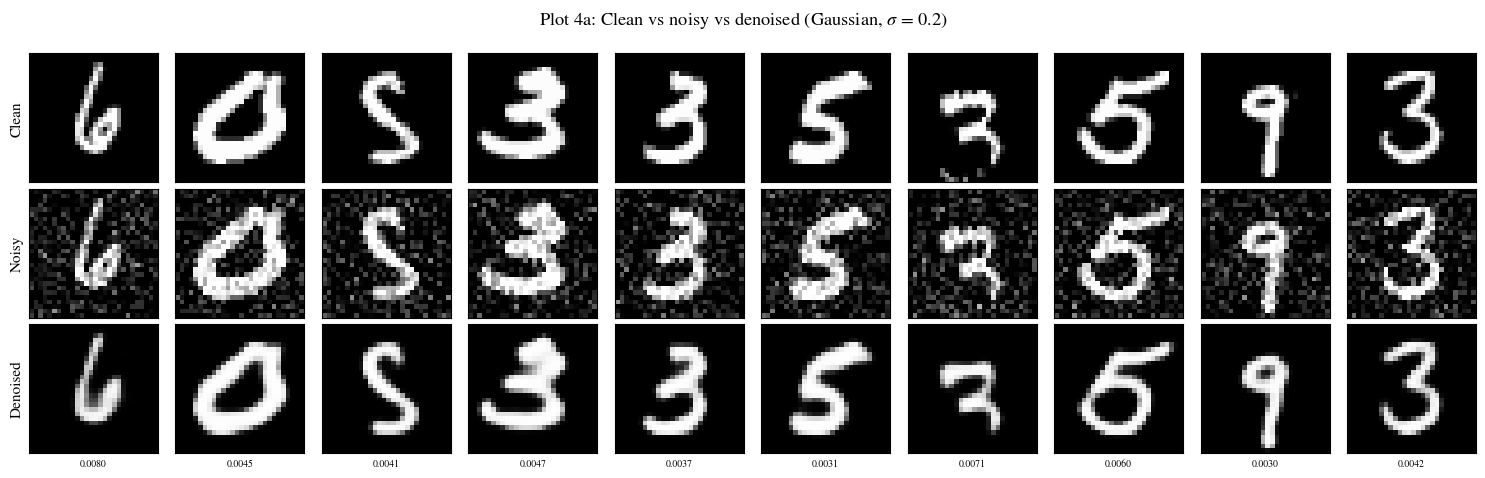

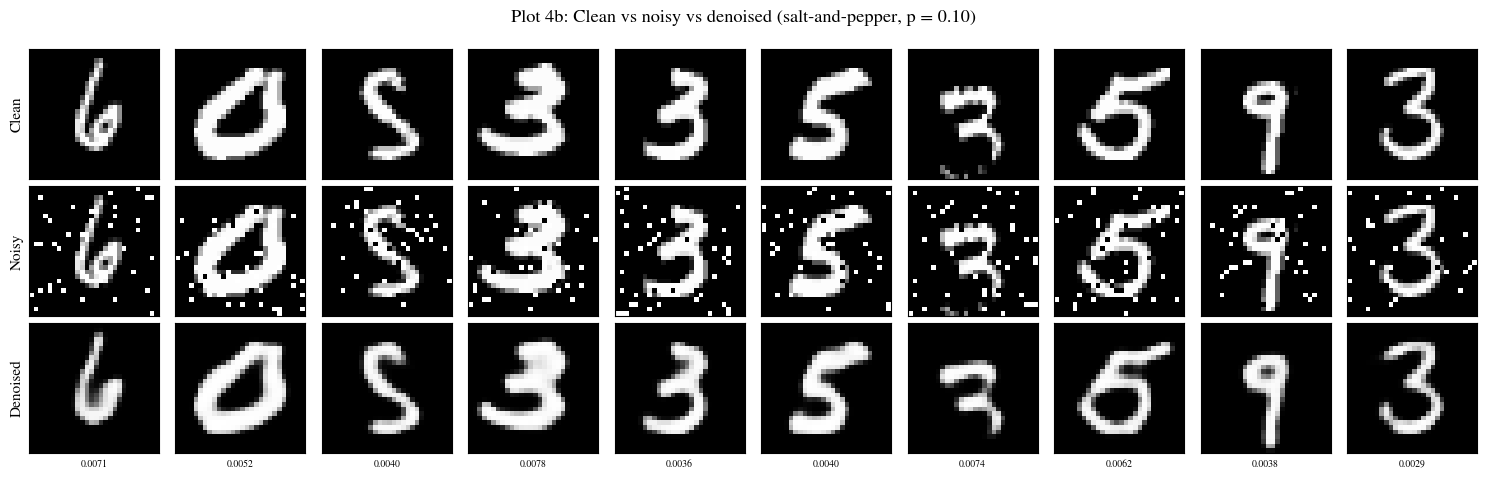

In [21]:
# EXP7 T3 CELL 5 - PLOT 4: CLEAN vs NOISY vs DENOISED. Ten test images for the headline Gaussian model (sigma = 0.2) and, as a second
# figure, the salt-and-pepper model at p = 0.10. Rows: clean, noisy input, denoised output. Per-image MSE of the denoised image is shown below it.
def plot4(key, fname, title):
    n = 10
    fig, axes = plt.subplots(3, n, figsize=(1.5 * n, 4.8))
    for i in range(n):
        axes[0, i].imshow(x_test[i, ..., 0], cmap="gray", vmin=0, vmax=1)
        axes[1, i].imshow(noisy_test[key][i, ..., 0], cmap="gray", vmin=0, vmax=1)
        axes[2, i].imshow(dae_recon[key][i, ..., 0], cmap="gray", vmin=0, vmax=1)
        axes[2, i].set_xlabel(f"{np.mean((x_test[i]-dae_recon[key][i])**2):.4f}", fontsize=7)
        for r in range(3):
            axes[r, i].set_xticks([]); axes[r, i].set_yticks([])
    axes[0, 0].set_ylabel("Clean"); axes[1, 0].set_ylabel("Noisy"); axes[2, 0].set_ylabel("Denoised")
    plt.suptitle(title); plt.tight_layout(); save_fig(fname); plt.show()

plot4(("gaussian", 0.2), "plot4_denoise_gaussian", r"Plot 4a: Clean vs noisy vs denoised (Gaussian, $\sigma$ = 0.2)")
plot4(("sp", 0.10),      "plot4_denoise_sp",       "Plot 4b: Clean vs noisy vs denoised (salt-and-pepper, p = 0.10)")

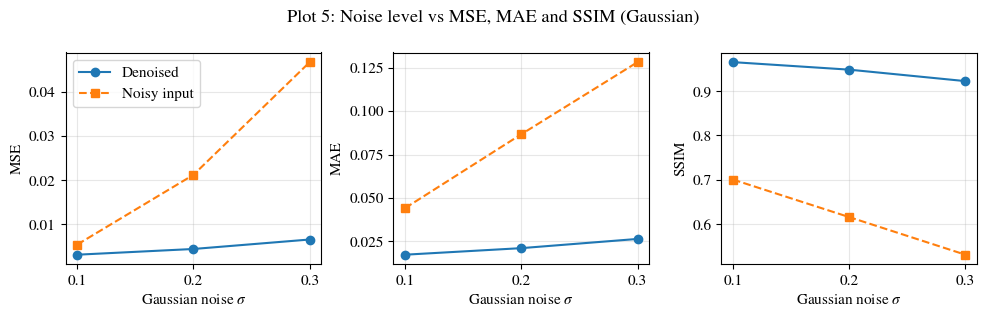

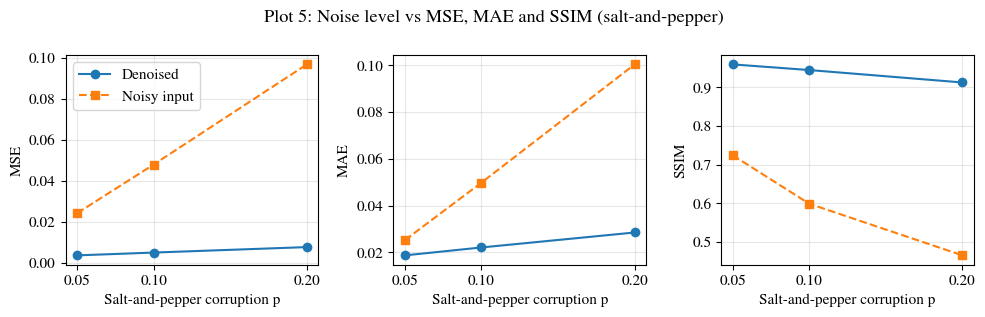

In [22]:
# EXP7 T3 CELL 6 - PLOT 5: NOISE LEVEL vs RECONSTRUCTION QUALITY. One figure per noise type, with three separate panels (MSE, MAE, SSIM),
# each with its own y-axis so incompatible scales are never mixed. Solid = denoised output, dashed = the noisy input (no denoising).
for kind, levels, xlabel, fname in [("gaussian", GAUSS_SIGMAS, r"Gaussian noise $\sigma$", "plot5_noise_gaussian"),
                                    ("sp", SP_PROBS, "Salt-and-pepper corruption p", "plot5_noise_sp")]:
    fig, axes = plt.subplots(1, 3, figsize=(10, 3.2))
    for ax, met in zip(axes, ["MSE", "MAE", "SSIM"]):
        ax.plot(levels, [dae_metrics[(kind, lv)]["denoised"][met] for lv in levels], "o-", label="Denoised")
        ax.plot(levels, [dae_metrics[(kind, lv)]["noisy"][met] for lv in levels], "s--", label="Noisy input")
        ax.set_xticks(levels); ax.set_xlabel(xlabel); ax.set_ylabel(met); ax.grid(alpha=0.3)
    axes[0].legend()
    plt.suptitle(f"Plot 5: Noise level vs MSE, MAE and SSIM ({'Gaussian' if kind == 'gaussian' else 'salt-and-pepper'})")
    plt.tight_layout(); save_fig(fname); plt.show()

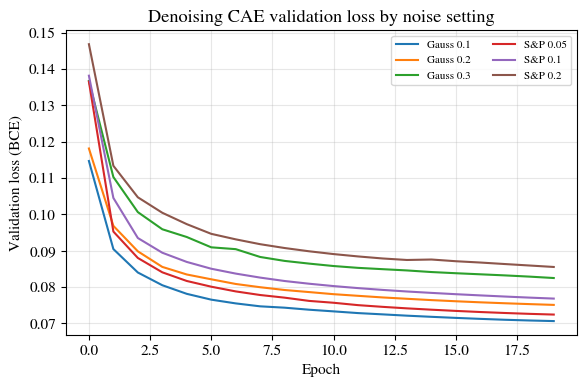

In [23]:
# EXP7 T3 CELL 7 - TRAINING vs VALIDATION LOSS OF THE DENOISING CAEs. Not a required plot, but it lets you say whether the denoiser converges
# and overfits, and shows how the final loss floor rises with noise level (a harder task cannot reach as low a loss).
plt.figure(figsize=(6, 4))
for key in KEYS:
    plt.plot(dae_hist[key].history["val_loss"], label=f"{'Gauss' if key[0]=='gaussian' else 'S&P'} {key[1]}")
plt.xlabel("Epoch"); plt.ylabel("Validation loss (BCE)")
plt.title("Denoising CAE validation loss by noise setting")
plt.legend(ncol=2, fontsize=8); plt.grid(alpha=0.3); plt.tight_layout()
save_fig("dae_val_loss"); plt.show()

In [24]:
# EXP7 T4 CELL 1 - VAE ENCODER AND DECODER. Encoder: two strided convs (28->14->7), flatten, dense 16, then two heads giving mu and log(sigma^2)
# for a 2-D latent. Decoder: dense to 7x7x64, two ConvTranspose upsampling layers (7->14->28), sigmoid output. latent_dim is a parameter so the
# same function serves the optional dz = 8 exercise. Sampling is done in the VAE class (next cell) so the reparameterization is explicit.
LATENT = 2

def build_vae_parts(latent_dim=2):
    enc_in = keras.Input((28, 28, 1))
    h = layers.Conv2D(32, 3, strides=2, activation="relu", padding="same")(enc_in)   # 14x14x32
    h = layers.Conv2D(64, 3, strides=2, activation="relu", padding="same")(h)        # 7x7x64
    h = layers.Flatten()(h)
    h = layers.Dense(16, activation="relu")(h)
    z_mean = layers.Dense(latent_dim, name="z_mean")(h)
    z_log_var = layers.Dense(latent_dim, name="z_log_var")(h)
    encoder = keras.Model(enc_in, [z_mean, z_log_var], name="vae_encoder")

    dec_in = keras.Input((latent_dim,))
    h = layers.Dense(7 * 7 * 64, activation="relu")(dec_in)
    h = layers.Reshape((7, 7, 64))(h)
    h = layers.Conv2DTranspose(64, 3, strides=2, activation="relu", padding="same")(h)  # 14x14x64
    h = layers.Conv2DTranspose(32, 3, strides=2, activation="relu", padding="same")(h)  # 28x28x32
    dec_out = layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")(h)     # 28x28x1
    decoder = keras.Model(dec_in, dec_out, name="vae_decoder")
    return encoder, decoder

encoder, decoder = build_vae_parts(LATENT)
encoder.summary(); decoder.summary()
print("VAE params (encoder + decoder):", f"{encoder.count_params() + decoder.count_params():,}")

Model: "vae_encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_12      │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_35 (Conv2D)  │ (None, 14, 14,    │        320 │ input_layer_12[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_36 (Conv2D)  │ (None, 7, 7, 64)  │     18,496 │ conv2d_35[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_5 (Flatten) │ (None, 3136)      │          0 │ conv2d_36[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_25 (Dense)    │ (None, 16)        │     50,192 │ flatten_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │         34 │ dense_25[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │         34 │ dense_25[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 69,076 (269.83 KB)

 Trainable params: 69,076 (269.83 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)     │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 3136)           │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_5 (Reshape)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │           289 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,089 (254.25 KB)

 Trainable params: 65,089 (254.25 KB)

 Non-trainable params: 0 (0.00 B)

VAE params (encoder + decoder): 134,165


In [29]:
# EXP7 T4 CELL 2 - VAE MODEL. reparameterize implements z = mu + sigma * eps with eps ~ N(0, I), which keeps the sampling step differentiable.
# Loss = reconstruction BCE (summed over the 784 pixels, averaged over the batch) + KL( q(z|x) || N(0,I) ) summed over latent dimensions.
# train_step/test_step track total, reconstruction and KL loss separately, so validation curves exist for all three.
# The loss method is named _compute_losses because Keras 3 reserves the attribute name _losses for its own internal list.
class VAE(keras.Model):
    def __init__(self, encoder, decoder, beta=1.0, **kwargs):
        super().__init__(**kwargs)
        self.encoder, self.decoder, self.beta = encoder, decoder, beta
        self.total_tracker = keras.metrics.Mean(name="loss")
        self.rec_tracker = keras.metrics.Mean(name="recon_loss")
        self.kl_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_tracker, self.rec_tracker, self.kl_tracker]

    def reparameterize(self, z_mean, z_log_var):
        eps = tf.random.normal(tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * eps

    def _compute_losses(self, x):
        z_mean, z_log_var = self.encoder(x)
        z = self.reparameterize(z_mean, z_log_var)
        x_hat = self.decoder(z)
        rec = tf.reduce_mean(tf.reduce_sum(keras.losses.binary_crossentropy(x, x_hat), axis=(1, 2)))
        kl = tf.reduce_mean(-0.5 * tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1))
        return rec, kl

    def _log(self, rec, kl):
        self.total_tracker.update_state(rec + self.beta * kl)
        self.rec_tracker.update_state(rec)
        self.kl_tracker.update_state(kl)
        return {m.name: m.result() for m in self.metrics}

    def train_step(self, data):
        if isinstance(data, (tuple, list)): data = data[0]
        with tf.GradientTape() as tape:
            rec, kl = self._compute_losses(data)
            total = rec + self.beta * kl
        grads = tape.gradient(total, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        return self._log(rec, kl)

    def test_step(self, data):
        if isinstance(data, (tuple, list)): data = data[0]
        rec, kl = self._compute_losses(data)
        return self._log(rec, kl)

vae = VAE(encoder, decoder, beta=1.0)
vae.compile(optimizer=keras.optimizers.Adam(1e-3))
print("VAE ready (beta = 1.0, latent dim = %d)" % LATENT)

VAE ready (beta = 1.0, latent dim = 2)


In [30]:
# EXP7 T4 CELL 3 - TRAIN THE VAE. 30 epochs, batch 128, Adam 1e-3, same 10% validation split as the other models. No labels are given to
# the model: the input is the image only. Wall-clock training time is stored for the consolidated table.
tf.random.set_seed(SEED)
t0 = time.perf_counter()
vae_hist = vae.fit(x_train, epochs=30, batch_size=128, validation_split=0.1, shuffle=True, verbose=2)
vae_time = time.perf_counter() - t0
print(f"training time: {vae_time:.1f}s")

Epoch 1/30
71/71 - 12s - 163ms/step - kl_loss: 0.8847 - loss: 322.4131 - recon_loss: 321.5282 - val_kl_loss: 0.7009 - val_loss: 215.4265 - val_recon_loss: 214.7256
Epoch 2/30
71/71 - 1s - 7ms/step - kl_loss: 0.5492 - loss: 213.0075 - recon_loss: 212.4582 - val_kl_loss: 0.5323 - val_loss: 208.7469 - val_recon_loss: 208.2146
Epoch 3/30
71/71 - 1s - 7ms/step - kl_loss: 1.6127 - loss: 206.7095 - recon_loss: 205.0968 - val_kl_loss: 2.9285 - val_loss: 202.6012 - val_recon_loss: 199.6727
Epoch 4/30
71/71 - 1s - 7ms/step - kl_loss: 2.8754 - loss: 201.6285 - recon_loss: 198.7531 - val_kl_loss: 3.2336 - val_loss: 199.7718 - val_recon_loss: 196.5381
Epoch 5/30
71/71 - 1s - 7ms/step - kl_loss: 3.1765 - loss: 198.7174 - recon_loss: 195.5409 - val_kl_loss: 3.4028 - val_loss: 196.2271 - val_recon_loss: 192.8244
Epoch 6/30
71/71 - 0s - 7ms/step - kl_loss: 3.3668 - loss: 196.1941 - recon_loss: 192.8273 - val_kl_loss: 3.4726 - val_loss: 193.8778 - val_recon_loss: 190.4052
Epoch 7/30
71/71 - 1s - 7ms/ste

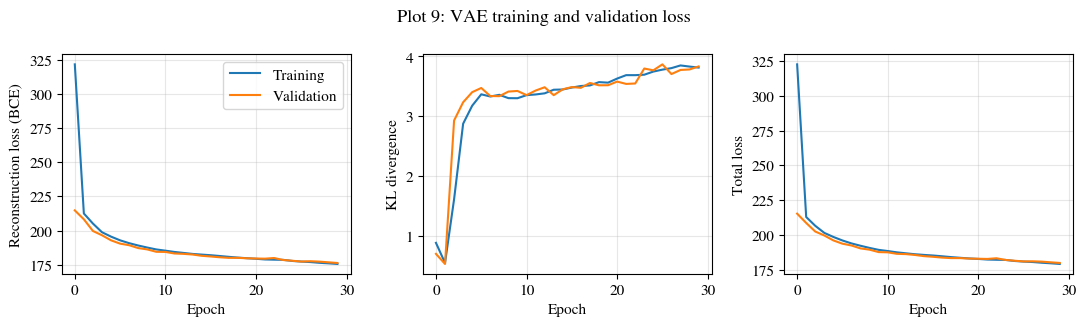

final train: rec 175.55 | KL 3.81 | total 179.37
final val  : rec 176.25 | KL 3.83 | total 180.08


In [31]:
# EXP7 T4 CELL 4 - PLOT 9: VAE TRAINING vs VALIDATION LOSS. Three separate panels with their own y-axes: reconstruction loss, KL loss and
# total loss. Watch whether the reconstruction and KL terms trade off against each other and whether validation separates from training.
H = vae_hist.history
fig, axes = plt.subplots(1, 3, figsize=(11, 3.3))
for ax, (k, ttl) in zip(axes, [("recon_loss", "Reconstruction loss (BCE)"), ("kl_loss", "KL divergence"), ("loss", "Total loss")]):
    ax.plot(H[k], label="Training"); ax.plot(H["val_" + k], label="Validation")
    ax.set_xlabel("Epoch"); ax.set_ylabel(ttl); ax.grid(alpha=0.3)
axes[0].legend()
plt.suptitle("Plot 9: VAE training and validation loss")
plt.tight_layout(); save_fig("plot9_vae_loss"); plt.show()
print("final train: rec %.2f | KL %.2f | total %.2f" % (H["recon_loss"][-1], H["kl_loss"][-1], H["loss"][-1]))
print("final val  : rec %.2f | KL %.2f | total %.2f" % (H["val_recon_loss"][-1], H["val_kl_loss"][-1], H["val_loss"][-1]))

In [32]:
# EXP7 T4 CELL 5 - VAE TEST LOSSES AND METRICS. Reconstruction, KL and total loss come from vae.evaluate on the 2,000 test images (z is sampled,
# as in training). MSE, MAE and SSIM are computed on the deterministic reconstruction decoder(mu), which is the usual way to evaluate a VAE.
# The encoded means and log-variances are kept for the latent plots, and the numbers are stored in RESULTS for the consolidated table.
tf.random.set_seed(SEED)
te = vae.evaluate(x_test, batch_size=128, verbose=0, return_dict=True)
z_mean_te, z_logvar_te = encoder.predict(x_test, verbose=0)
vae_recon = decoder.predict(z_mean_te, verbose=0)
m = evaluate_recon(x_test, vae_recon)
vae_params = encoder.count_params() + decoder.count_params()
RESULTS["VAE"] = {**m, "Params": vae_params, "Time": vae_time}
VAE_LOSS = {"rec": te["recon_loss"], "kl": te["kl_loss"], "total": te["loss"]}

print(f"{'VAE Metric':<22}{'Value':>12}")
print(f"{'Reconstruction Loss':<22}{VAE_LOSS['rec']:>12.3f}")
print(f"{'KL Loss':<22}{VAE_LOSS['kl']:>12.3f}")
print(f"{'Total Loss':<22}{VAE_LOSS['total']:>12.3f}")
print(f"{'Test MSE':<22}{m['MSE']:>12.5f}")
print(f"{'Test MAE':<22}{m['MAE']:>12.5f}")
print(f"{'Mean SSIM':<22}{m['SSIM']:>12.4f}")
print("Params:", f"{vae_params:,}", "| Time: %.1fs" % vae_time)

print(f"\n{'Model':<20}{'MSE':>10}{'MAE':>10}{'SSIM':>10}{'Params':>12}")
for k in ["FC Autoencoder", "Conv. Autoencoder", "Denoising CAE", "VAE"]:
    if k in RESULTS:
        r = RESULTS[k]; print(f"{k:<20}{r['MSE']:>10.5f}{r['MAE']:>10.5f}{r['SSIM']:>10.4f}{r['Params']:>12,}")

VAE Metric                   Value
Reconstruction Loss        176.266
KL Loss                      3.857
Total Loss                 180.123
Test MSE                   0.05474
Test MAE                   0.12666
Mean SSIM                   0.3661
Params: 134,165 | Time: 26.9s

Model                      MSE       MAE      SSIM      Params
FC Autoencoder         0.01992   0.05442    0.7749     211,040
Conv. Autoencoder      0.00264   0.01554    0.9725      74,497
Denoising CAE          0.00444   0.02111    0.9480      74,497
VAE                    0.05474   0.12666    0.3661     134,165


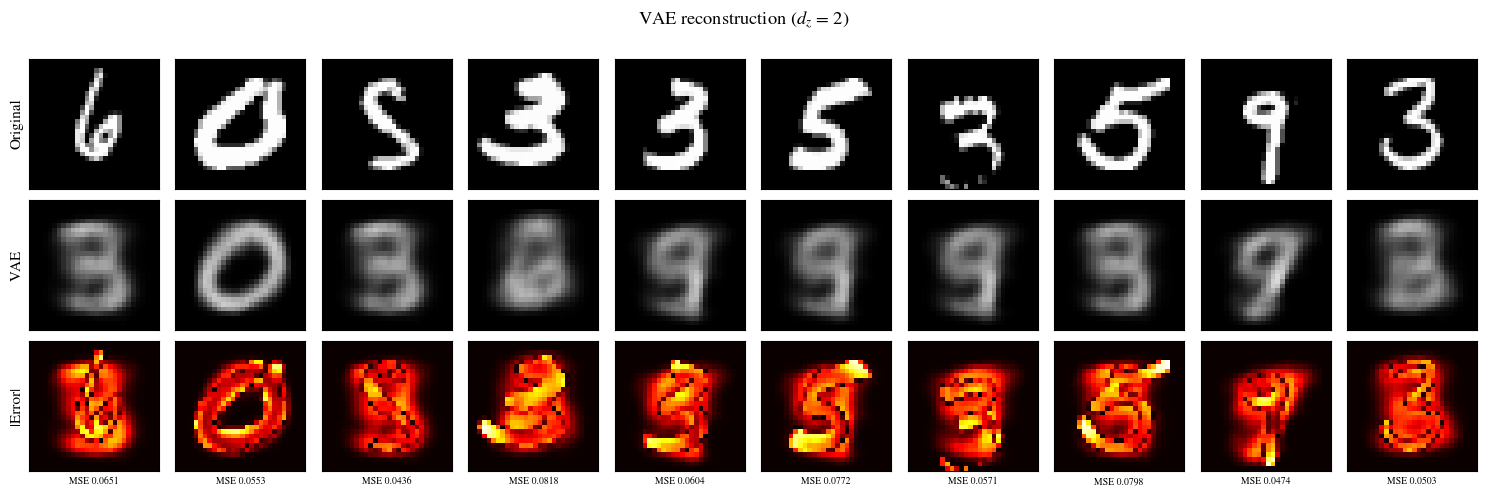

In [33]:
# EXP7 T4 CELL 6 - VAE RECONSTRUCTIONS. Original, reconstruction decoder(mu) and absolute error for the first 10 test images, the same three-part
# display the manual requires for every reconstruction model. Expect blurrier output than the CAE because the whole digit passes through 2 numbers.
n = 10
fig, axes = plt.subplots(3, n, figsize=(1.5 * n, 5))
for i in range(n):
    axes[0, i].imshow(x_test[i, ..., 0], cmap="gray", vmin=0, vmax=1)
    axes[1, i].imshow(vae_recon[i, ..., 0], cmap="gray", vmin=0, vmax=1)
    axes[2, i].imshow(np.abs(x_test[i, ..., 0] - vae_recon[i, ..., 0]), cmap="hot", vmin=0, vmax=1)
    axes[2, i].set_xlabel(f"MSE {np.mean((x_test[i]-vae_recon[i])**2):.4f}", fontsize=7)
    for r in range(3):
        axes[r, i].set_xticks([]); axes[r, i].set_yticks([])
axes[0, 0].set_ylabel("Original"); axes[1, 0].set_ylabel("VAE"); axes[2, 0].set_ylabel("|Error|")
plt.suptitle("VAE reconstruction ($d_z$ = 2)")
plt.tight_layout(); save_fig("vae_recon"); plt.show()

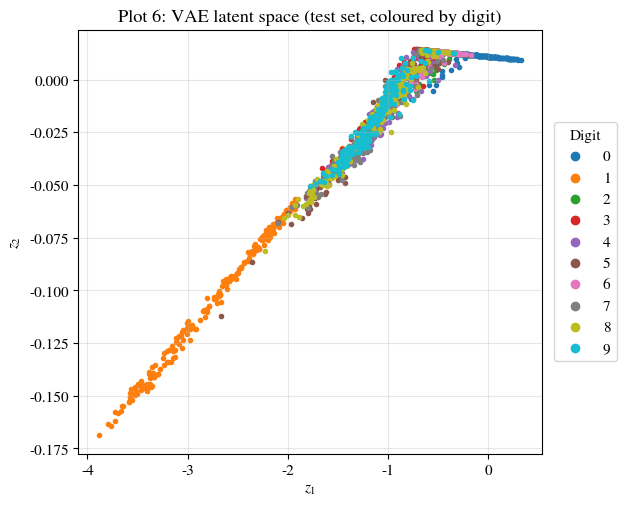

mean of mu per dim      : [-1.01  -0.016]
std of mu per dim       : [0.757 0.038]
mean sigma per dim      : [0.038 0.846]
KL per dim (nats)       : [3.813 0.044] | total 3.857
5-NN digit accuracy in the 2-D latent space: 0.412  (a measure of how much digit classes overlap)


In [34]:
# EXP7 T4 CELL 7 - PLOT 6: VAE LATENT SPACE. Each test image is plotted at its encoded mean (z1, z2), coloured by digit label. Labels are used only
# for colouring and for the 5-NN score below; the VAE never saw them. No transparency is used, so the EPS output is correct. The printed statistics
# describe the latent distribution (are the means centred near 0, is the spread close to 1, how much KL does each dimension carry).
from sklearn.neighbors import KNeighborsClassifier
cmap = plt.get_cmap("tab10")
fig, ax = plt.subplots(figsize=(6.4, 5.2))
for d in range(10):
    pts = z_mean_te[y_test == d]
    ax.scatter(pts[:, 0], pts[:, 1], s=9, color=cmap(d), label=str(d))
ax.set_xlabel("$z_1$"); ax.set_ylabel("$z_2$"); ax.grid(alpha=0.3)
ax.legend(title="Digit", ncol=1, markerscale=2, loc="center left", bbox_to_anchor=(1.01, 0.5))
ax.set_title("Plot 6: VAE latent space (test set, coloured by digit)")
plt.tight_layout(); save_fig("plot6_vae_latent"); plt.show()

sigma = np.exp(0.5 * z_logvar_te)
kl_dim = -0.5 * np.mean(1 + z_logvar_te - z_mean_te**2 - np.exp(z_logvar_te), axis=0)
print("mean of mu per dim      :", np.round(z_mean_te.mean(0), 3))
print("std of mu per dim       :", np.round(z_mean_te.std(0), 3))
print("mean sigma per dim      :", np.round(sigma.mean(0), 3))
print("KL per dim (nats)       :", np.round(kl_dim, 3), "| total %.3f" % kl_dim.sum())
z_tr_mean = encoder.predict(x_train, verbose=0)[0]
knn = KNeighborsClassifier(5).fit(z_tr_mean, y_train)
print("5-NN digit accuracy in the 2-D latent space: %.3f  (a measure of how much digit classes overlap)" % knn.score(z_mean_te, y_test))

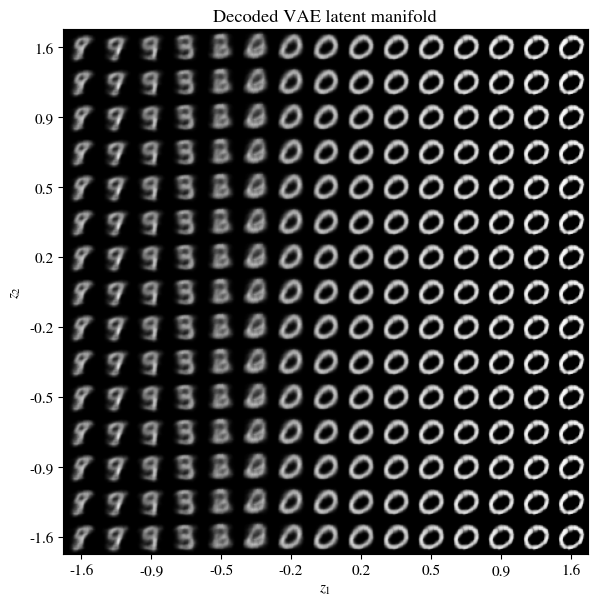

In [35]:
# EXP7 T4 CELL 8 - DECODED LATENT MANIFOLD (supporting figure). Decodes a 15x15 grid of latent points covering the central region of N(0, I)
# (5th to 95th percentile of each axis) so you can see how digit identity and style vary across the 2-D plane. Only valid for a 2-D latent.
from scipy.stats import norm
n = 15
zs = norm.ppf(np.linspace(0.05, 0.95, n))
pairs = np.array([[xv, yv] for yv in zs[::-1] for xv in zs], dtype="float32")
dec = decoder.predict(pairs, verbose=0)[..., 0].reshape(n, n, 28, 28)
canvas = dec.transpose(0, 2, 1, 3).reshape(n * 28, n * 28)
plt.figure(figsize=(6.2, 6.2))
plt.imshow(canvas, cmap="gray", vmin=0, vmax=1)
plt.xticks(np.arange(14, n * 28, 28)[::2], np.round(zs[::2], 1)); plt.yticks(np.arange(14, n * 28, 28)[::2], np.round(zs[::-1][::2], 1))
plt.xlabel("$z_1$"); plt.ylabel("$z_2$"); plt.title("Decoded VAE latent manifold")
plt.tight_layout(); save_fig("vae_manifold"); plt.show()

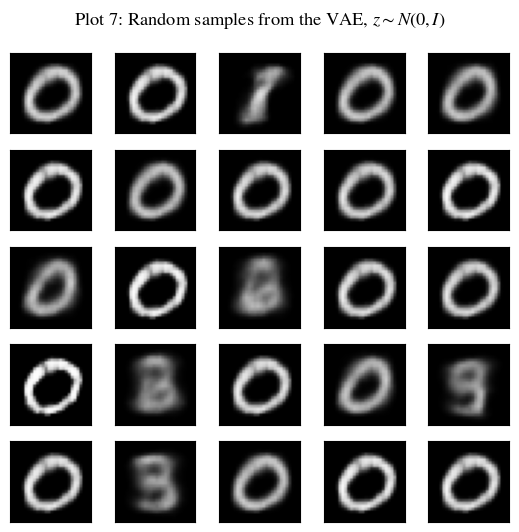

In [36]:
# EXP7 T4 CELL 9 - PLOT 7: RANDOMLY GENERATED IMAGES. 25 latent vectors drawn from the prior z ~ N(0, I) with a fixed seed, passed through the
# decoder only (no input image is used). This is generation, as opposed to reconstruction. Note which samples look like clear digits and which are ambiguous.
rng_gen = np.random.default_rng(SEED)
z_rand = rng_gen.standard_normal((25, LATENT)).astype("float32")
gen = decoder.predict(z_rand, verbose=0)
fig, axes = plt.subplots(5, 5, figsize=(5.4, 5.4))
for k, ax in enumerate(axes.ravel()):
    ax.imshow(gen[k, ..., 0], cmap="gray", vmin=0, vmax=1); ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("Plot 7: Random samples from the VAE, $z \\sim N(0, I)$")
plt.tight_layout(); save_fig("plot7_vae_samples"); plt.show()

1 -> 7: step MSE mean 0.0009 | max 0.0012 | max/mean 1.38
3 -> 8: step MSE mean 0.0005 | max 0.0007 | max/mean 1.32
0 -> 6: step MSE mean 0.0020 | max 0.0039 | max/mean 1.98


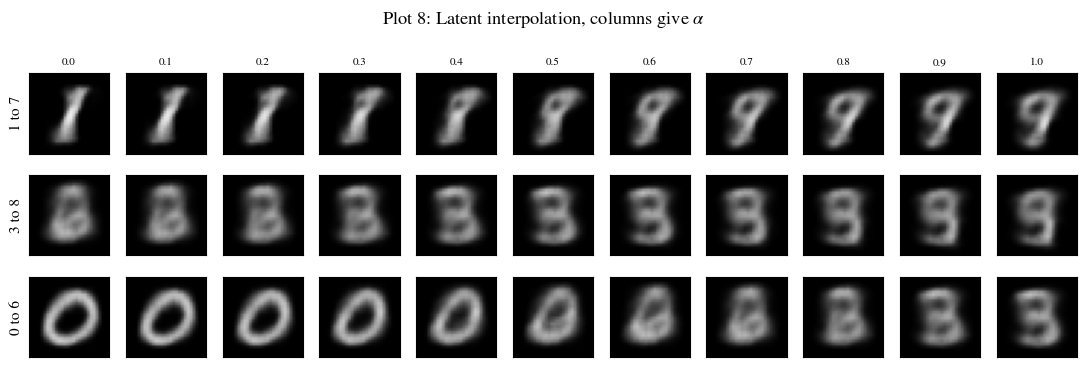

In [37]:
# EXP7 T4 CELL 10 - PLOT 8: LATENT-SPACE INTERPOLATION. For three digit pairs, takes the encoded means zA and zB of two test images and decodes
# z(alpha) = (1 - alpha) zA + alpha zB for alpha = 0, 0.1, ..., 1. The printed step sizes (MSE between consecutive decoded frames) give a
# number for smoothness: a smooth path has similar step sizes, a jump shows up as one large step.
pairs_lbl = [(1, 7), (3, 8), (0, 6)]
alphas = np.linspace(0, 1, 11)
fig, axes = plt.subplots(len(pairs_lbl), len(alphas), figsize=(1.0 * len(alphas), 1.15 * len(pairs_lbl) + 0.4))
for r, (a_lbl, b_lbl) in enumerate(pairs_lbl):
    ia, ib = np.where(y_test == a_lbl)[0][0], np.where(y_test == b_lbl)[0][0]
    zA, zB = z_mean_te[ia], z_mean_te[ib]
    zint = np.array([(1 - a) * zA + a * zB for a in alphas], dtype="float32")
    dec = decoder.predict(zint, verbose=0)
    for c in range(len(alphas)):
        axes[r, c].imshow(dec[c, ..., 0], cmap="gray", vmin=0, vmax=1)
        axes[r, c].set_xticks([]); axes[r, c].set_yticks([])
        if r == 0: axes[r, c].set_title(f"{alphas[c]:.1f}", fontsize=8)
    axes[r, 0].set_ylabel(f"{a_lbl} to {b_lbl}")
    steps = np.mean((dec[1:] - dec[:-1]) ** 2, axis=(1, 2, 3))
    print(f"{a_lbl} -> {b_lbl}: step MSE mean {steps.mean():.4f} | max {steps.max():.4f} | max/mean {steps.max()/steps.mean():.2f}")
plt.suptitle(r"Plot 8: Latent interpolation, columns give $\alpha$")
plt.tight_layout(); save_fig("plot8_vae_interp"); plt.show()

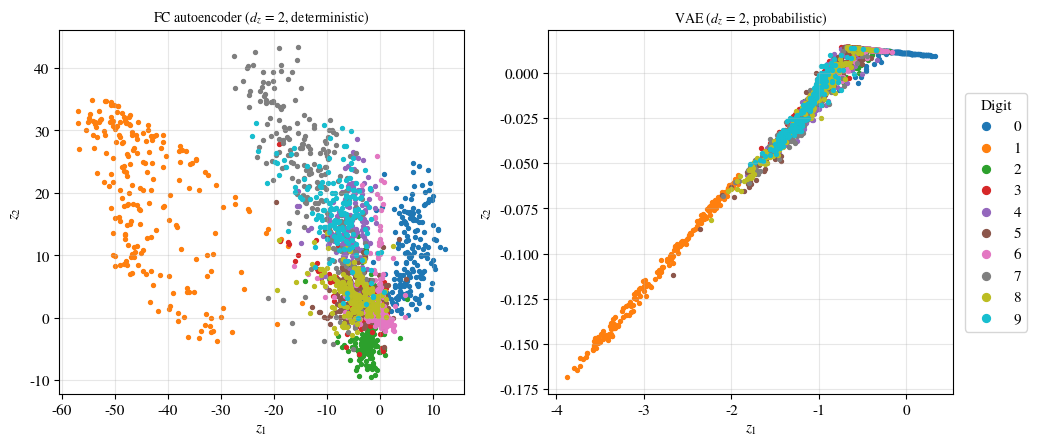

FC-AE latent  : std per dim [13.72 10.43] | 5-NN acc 0.588
VAE latent    : std per dim [0.76 0.04] | 5-NN acc 0.412


In [38]:
# EXP7 T4 CELL 11 - DETERMINISTIC vs PROBABILISTIC LATENT. Trains a fresh FC autoencoder with dz = 2 (same protocol as T1) only to get its 2-D
# codes, then plots them next to the VAE codes. This supports the mandatory inference on deterministic vs variational latent representations:
# compare the spread, the empty gaps, and the digit overlap. The same 5-NN score is computed for both.
tf.random.set_seed(SEED)
fc2_ae, fc2_enc = build_fc_ae(2, name="fc_ae_dz2_compare")
fc2_ae.fit(x_train, x_train, epochs=20, batch_size=128, validation_split=0.1, shuffle=True, verbose=0)
z_fc2 = fc2_enc.predict(x_test, verbose=0)
knn_fc = KNeighborsClassifier(5).fit(fc2_enc.predict(x_train, verbose=0), y_train)

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.6))
for ax, Z, ttl in [(axes[0], z_fc2, "FC autoencoder ($d_z$ = 2, deterministic)"), (axes[1], z_mean_te, "VAE ($d_z$ = 2, probabilistic)")]:
    for d in range(10):
        ax.scatter(Z[y_test == d, 0], Z[y_test == d, 1], s=8, color=cmap(d), label=str(d))
    ax.set_xlabel("$z_1$"); ax.set_ylabel("$z_2$"); ax.set_title(ttl, fontsize=10); ax.grid(alpha=0.3)
axes[1].legend(title="Digit", markerscale=2, loc="center left", bbox_to_anchor=(1.01, 0.5))
plt.tight_layout(); save_fig("latent_fc_vs_vae"); plt.show()
print("FC-AE latent  : std per dim", np.round(z_fc2.std(0), 2), "| 5-NN acc %.3f" % knn_fc.score(z_fc2, y_test))
print("VAE latent    : std per dim", np.round(z_mean_te.std(0), 2), "| 5-NN acc %.3f" % knn.score(z_mean_te, y_test))

In [39]:
# EXP7 T5 CELL 1 - PER-IMAGE RECONSTRUCTION ERROR e_i = mean over pixels of (x - xhat)^2, for the FC-AE, CAE and VAE on the 2,000 test images.
# Also computes per-image SSIM (used later to relate error to visual quality) and prints the summary statistics the manual asks for:
# typical range, concentration vs spread, and how many images are high-error outliers (above mean + 2 std).
from scipy.stats import spearmanr

def per_image_ssim(x, xhat):
    x = x.reshape(-1, 28, 28, 1); xhat = xhat.reshape(-1, 28, 28, 1)
    return np.array([ssim_fn(a[..., 0], b[..., 0], data_range=1.0) for a, b in zip(x, xhat)])

ERR_MODELS = {"FC-AE": fc_recon, "CAE": cae_recon, "VAE": vae_recon}
err, ssim_i = {}, {}
for name, rec in ERR_MODELS.items():
    err[name] = per_image_mse(x_test, rec)
    ssim_i[name] = per_image_ssim(x_test, rec)

print(f"{'Model':<7}{'mean':>9}{'median':>9}{'std':>9}{'min':>9}{'p90':>9}{'p99':>9}{'max':>9}{'#>mean+2sd':>12}")
for name, e in err.items():
    thr = e.mean() + 2 * e.std()
    print(f"{name:<7}{e.mean():>9.5f}{np.median(e):>9.5f}{e.std():>9.5f}{e.min():>9.5f}"
          f"{np.percentile(e, 90):>9.5f}{np.percentile(e, 99):>9.5f}{e.max():>9.5f}{(e > thr).sum():>12d}")

Model       mean   median      std      min      p90      p99      max  #>mean+2sd
FC-AE    0.01992  0.01894  0.01038  0.00184  0.03375  0.04822  0.07570          73
CAE      0.00264  0.00243  0.00137  0.00039  0.00437  0.00724  0.01145          85
VAE      0.05474  0.05496  0.01890  0.00513  0.07681  0.10548  0.14258          46


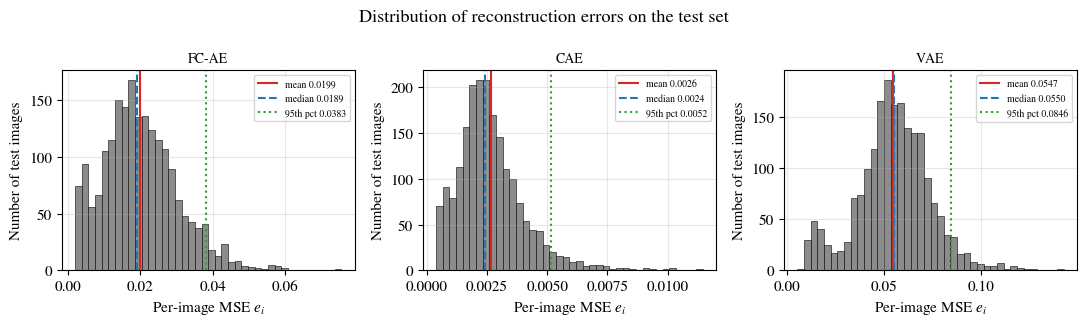

In [40]:
# EXP7 T5 CELL 2 - HISTOGRAM OF PER-IMAGE RECONSTRUCTION ERROR. One panel per model with its own axes (the models have different error scales).
# Vertical lines mark the mean, median and 95th percentile so the typical range and the tail are visible. No transparency is used (EPS-safe).
fig, axes = plt.subplots(1, 3, figsize=(11, 3.3))
for ax, (name, e) in zip(axes, err.items()):
    ax.hist(e, bins=40, color="0.55", edgecolor="black", linewidth=0.4)
    ax.axvline(e.mean(), color="tab:red", ls="-", label=f"mean {e.mean():.4f}")
    ax.axvline(np.median(e), color="tab:blue", ls="--", label=f"median {np.median(e):.4f}")
    ax.axvline(np.percentile(e, 95), color="tab:green", ls=":", label=f"95th pct {np.percentile(e, 95):.4f}")
    ax.set_xlabel("Per-image MSE $e_i$"); ax.set_ylabel("Number of test images")
    ax.set_title(name, fontsize=10); ax.legend(fontsize=7); ax.grid(alpha=0.3)
plt.suptitle("Distribution of reconstruction errors on the test set")
plt.tight_layout(); save_fig("error_distribution"); plt.show()

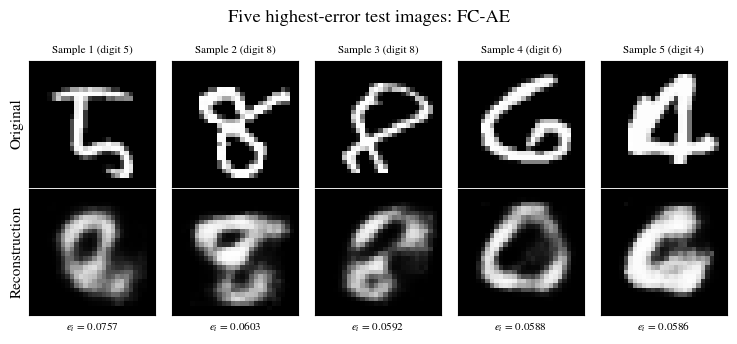

FC-AE: #1 idx 483 digit 5 e=0.0757 | #2 idx 1964 digit 8 e=0.0603 | #3 idx 19 digit 8 e=0.0592 | #4 idx 687 digit 6 e=0.0588 | #5 idx 971 digit 4 e=0.0586


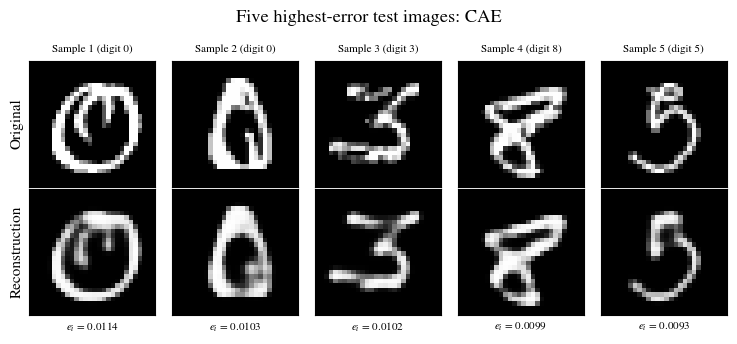

CAE: #1 idx 1134 digit 0 e=0.0114 | #2 idx 829 digit 0 e=0.0103 | #3 idx 1130 digit 3 e=0.0102 | #4 idx 954 digit 8 e=0.0099 | #5 idx 782 digit 5 e=0.0093


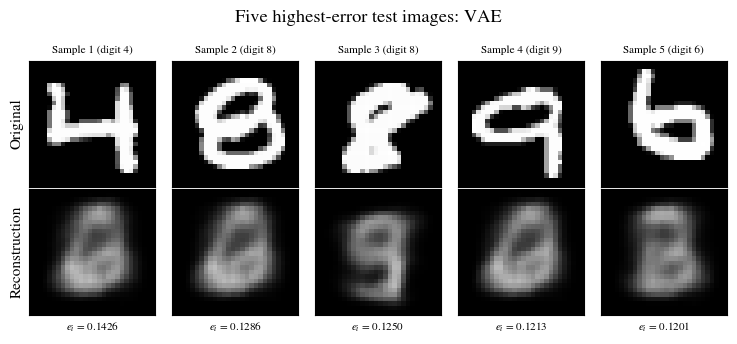

VAE: #1 idx 1626 digit 4 e=0.1426 | #2 idx 1816 digit 8 e=0.1286 | #3 idx 593 digit 8 e=0.1250 | #4 idx 349 digit 9 e=0.1213 | #5 idx 15 digit 6 e=0.1201


In [41]:
# EXP7 T5 CELL 3 - FIVE HIGHEST-ERROR TEST IMAGES for each model: original on top, reconstruction below, with the digit label and e_i.
# The label is used only for the caption. Also prints the indices, labels and errors as a table for the report.
def worst5(name, rec):
    order = np.argsort(err[name])[::-1][:5]
    fig, axes = plt.subplots(2, 5, figsize=(7.5, 3.4))
    for c, i in enumerate(order):
        axes[0, c].imshow(x_test[i, ..., 0], cmap="gray", vmin=0, vmax=1)
        axes[1, c].imshow(rec[i, ..., 0], cmap="gray", vmin=0, vmax=1)
        axes[0, c].set_title(f"Sample {c+1} (digit {y_test[i]})", fontsize=8)
        axes[1, c].set_xlabel(f"$e_i$ = {err[name][i]:.4f}", fontsize=8)
        for r in range(2):
            axes[r, c].set_xticks([]); axes[r, c].set_yticks([])
    axes[0, 0].set_ylabel("Original"); axes[1, 0].set_ylabel("Reconstruction")
    plt.suptitle(f"Five highest-error test images: {name}")
    plt.tight_layout(); save_fig(f"worst5_{name.lower().replace('-', '')}"); plt.show()
    print(f"{name}: " + " | ".join(f"#{c+1} idx {i} digit {y_test[i]} e={err[name][i]:.4f}" for c, i in enumerate(order)))

for name, rec in ERR_MODELS.items():
    worst5(name, rec)

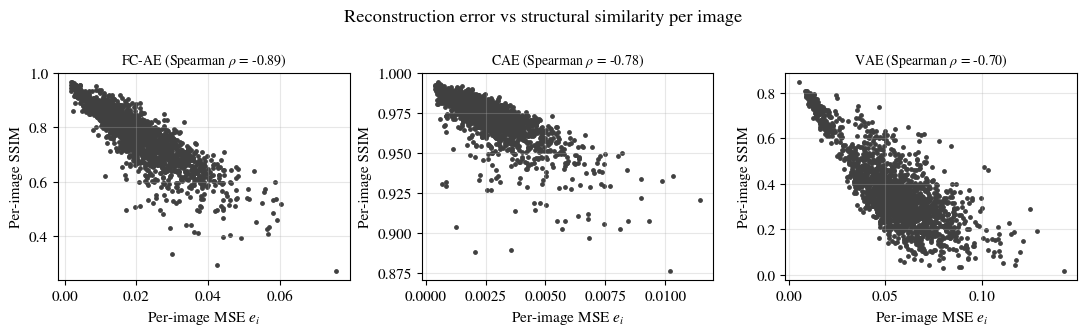

In [42]:
# EXP7 T5 CELL 4 - RELATIONSHIP BETWEEN RECONSTRUCTION ERROR AND VISUAL QUALITY. Scatter of per-image MSE against per-image SSIM for each model
# with the Spearman rank correlation printed in the title. A strongly negative correlation means high-error images also look structurally worse.
fig, axes = plt.subplots(1, 3, figsize=(11, 3.4))
for ax, name in zip(axes, err):
    rho = spearmanr(err[name], ssim_i[name])[0]
    ax.scatter(err[name], ssim_i[name], s=6, color="0.25")
    ax.set_xlabel("Per-image MSE $e_i$"); ax.set_ylabel("Per-image SSIM"); ax.grid(alpha=0.3)
    ax.set_title(f"{name} (Spearman $\\rho$ = {rho:.2f})", fontsize=10)
plt.suptitle("Reconstruction error vs structural similarity per image")
plt.tight_layout(); save_fig("error_vs_ssim"); plt.show()

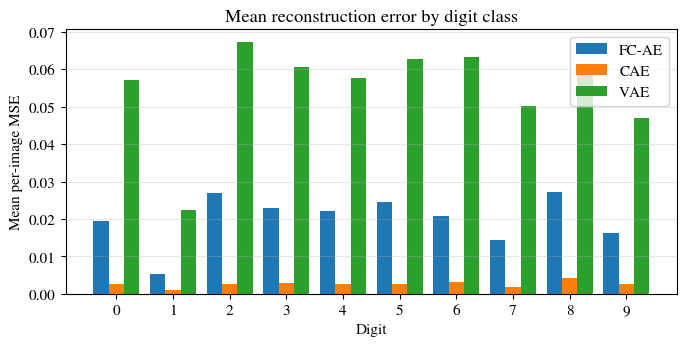

FC-AE  hardest digit 8 (0.0272) | easiest 1 (0.0053) | Spearman(error, ink) = 0.39
CAE    hardest digit 8 (0.0042) | easiest 1 (0.0009) | Spearman(error, ink) = 0.31
VAE    hardest digit 2 (0.0672) | easiest 1 (0.0224) | Spearman(error, ink) = 0.63


In [43]:
# EXP7 T5 CELL 5 - ERROR BY DIGIT CLASS AND BY AMOUNT OF INK. Left: mean per-image MSE for each digit, one bar group per model.
# Right: Spearman correlation between error and total pixel intensity ("ink"), printed. These give evidence for the short explanation of why
# the worst images are hard (for example, thick or complex digits such as 8, or unusual writing styles, tend to have more ink and detail).
ink = x_test.reshape(len(x_test), -1).sum(1)
digits = np.arange(10); w = 0.27
fig, ax = plt.subplots(figsize=(7, 3.6))
for k, name in enumerate(err):
    ax.bar(digits + (k - 1) * w, [err[name][y_test == d].mean() for d in digits], width=w, label=name)
ax.set_xticks(digits); ax.set_xlabel("Digit"); ax.set_ylabel("Mean per-image MSE"); ax.legend(); ax.grid(alpha=0.3, axis="y")
ax.set_title("Mean reconstruction error by digit class")
plt.tight_layout(); save_fig("error_by_digit"); plt.show()

for name in err:
    d_mean = {d: err[name][y_test == d].mean() for d in digits}
    hardest = max(d_mean, key=d_mean.get); easiest = min(d_mean, key=d_mean.get)
    print(f"{name:<6} hardest digit {hardest} ({d_mean[hardest]:.4f}) | easiest {easiest} ({d_mean[easiest]:.4f}) | "
          f"Spearman(error, ink) = {spearmanr(err[name], ink)[0]:.2f}")

In [44]:
# EXP7 T6 CELL 1 - CONSOLIDATED RESULTS. Prints the manual's final table (MSE, MAE, SSIM, Parameters, Time) from the values stored in RESULTS
# by your own runs. The Denoising CAE row is the Gaussian sigma = 0.2 model, scored on denoised output vs the clean image, so its numbers
# measure a harder task (noisy input) and are not directly comparable to the plain reconstruction models. Also prints the VAE loss table
# and the latent-dimension table so all the numbers for the report are in one place.
ORDER = ["FC Autoencoder", "Conv. Autoencoder", "Denoising CAE", "VAE"]
print("CONSOLIDATED RESULTS (test set, 2,000 images)")
print(f"{'Model':<20}{'MSE':>10}{'MAE':>10}{'SSIM':>10}{'Params':>12}{'Time (s)':>10}")
for k in ORDER:
    r = RESULTS[k]
    print(f"{k:<20}{r['MSE']:>10.5f}{r['MAE']:>10.5f}{r['SSIM']:>10.4f}{r['Params']:>12,}{r['Time']:>10.1f}")

print("\nVAE loss table (per image, BCE summed over 784 pixels, KL summed over latent dims)")
for lbl, key in [("Reconstruction Loss", "rec"), ("KL Loss", "kl"), ("Total Loss", "total")]:
    print(f"{lbl:<22}{VAE_LOSS[key]:>10.3f}")

print("\nLatent-dimension study (FC-AE)")
print(f"{'Latent Dim':<12}{'MSE':>10}{'SSIM':>10}{'Params':>12}")
for dz in LATENT_DIMS:
    r = dz_results[dz]; print(f"{dz:<12}{r['MSE']:>10.5f}{r['SSIM']:>10.4f}{r['Params']:>12,}")

CONSOLIDATED RESULTS (test set, 2,000 images)
Model                      MSE       MAE      SSIM      Params  Time (s)
FC Autoencoder         0.01992   0.05442    0.7749     211,040      12.0
Conv. Autoencoder      0.00264   0.01554    0.9725      74,497      20.7
Denoising CAE          0.00444   0.02111    0.9480      74,497      17.8
VAE                    0.05474   0.12666    0.3661     134,165      26.9

VAE loss table (per image, BCE summed over 784 pixels, KL summed over latent dims)
Reconstruction Loss      176.266
KL Loss                    3.857
Total Loss               180.123

Latent-dimension study (FC-AE)
Latent Dim         MSE      SSIM      Params
2              0.04718    0.4729     210,130
8              0.02595    0.7107     210,520
16             0.02025    0.7712     211,040
32             0.01919    0.7814     212,080


In [45]:
# EXP7 T6 CELL 2 - EXPORT. Writes the consolidated table, VAE loss table and latent-dimension table to CSV and as LaTeX booktabs tables
# (ready to paste into Overleaf) inside the figs folder, then zips the whole folder so every EPS/PDF/PNG figure downloads in one file.
import csv, shutil
os.makedirs("figs", exist_ok=True)

with open("figs/consolidated_results.csv", "w", newline="") as f:
    w = csv.writer(f); w.writerow(["Model", "MSE", "MAE", "SSIM", "Params", "Time_s"])
    for k in ORDER:
        r = RESULTS[k]; w.writerow([k, f"{r['MSE']:.5f}", f"{r['MAE']:.5f}", f"{r['SSIM']:.4f}", r["Params"], f"{r['Time']:.1f}"])

tex = ["\\begin{table}[htbp]", "\\centering", "\\caption{Consolidated test-set results (2{,}000 images).}", "\\label{tab:consolidated}",
       "\\begin{tabular}{lrrrrr}", "\\toprule", "Model & MSE & MAE & SSIM & Parameters & Time (s) \\\\", "\\midrule"]
for k in ORDER:
    r = RESULTS[k]
    tex.append(f"{k} & {r['MSE']:.5f} & {r['MAE']:.5f} & {r['SSIM']:.4f} & {r['Params']:,} & {r['Time']:.1f} \\\\".replace(",", "{,}") if False
               else f"{k} & {r['MSE']:.5f} & {r['MAE']:.5f} & {r['SSIM']:.4f} & {r['Params']} & {r['Time']:.1f} \\\\")
tex += ["\\bottomrule", "\\end{tabular}", "\\end{table}", "",
        "\\begin{table}[htbp]", "\\centering", "\\caption{Latent-dimension study for the fully connected autoencoder.}", "\\label{tab:dz}",
        "\\begin{tabular}{rrrr}", "\\toprule", "Latent dimension & MSE & SSIM & Parameters \\\\", "\\midrule"]
for dz in LATENT_DIMS:
    r = dz_results[dz]; tex.append(f"{dz} & {r['MSE']:.5f} & {r['SSIM']:.4f} & {r['Params']} \\\\")
tex += ["\\bottomrule", "\\end{tabular}", "\\end{table}", "",
        "\\begin{table}[htbp]", "\\centering", "\\caption{VAE loss terms on the test set (per image).}", "\\label{tab:vae}",
        "\\begin{tabular}{lr}", "\\toprule", "Metric & Value \\\\", "\\midrule",
        f"Reconstruction loss & {VAE_LOSS['rec']:.3f} \\\\", f"KL loss & {VAE_LOSS['kl']:.3f} \\\\", f"Total loss & {VAE_LOSS['total']:.3f} \\\\",
        f"Test MSE & {RESULTS['VAE']['MSE']:.5f} \\\\", f"Test MAE & {RESULTS['VAE']['MAE']:.5f} \\\\", f"Mean SSIM & {RESULTS['VAE']['SSIM']:.4f} \\\\",
        "\\bottomrule", "\\end{tabular}", "\\end{table}"]
with open("figs/tables.tex", "w") as f:
    f.write("\n".join(tex))
print("\n".join(tex))

shutil.make_archive("figs", "zip", "figs")
print("\nCreated figs.zip (download it from the Colab file panel)")

\begin{table}[htbp]
\centering
\caption{Consolidated test-set results (2{,}000 images).}
\label{tab:consolidated}
\begin{tabular}{lrrrrr}
\toprule
Model & MSE & MAE & SSIM & Parameters & Time (s) \\
\midrule
FC Autoencoder & 0.01992 & 0.05442 & 0.7749 & 211040 & 12.0 \\
Conv. Autoencoder & 0.00264 & 0.01554 & 0.9725 & 74497 & 20.7 \\
Denoising CAE & 0.00444 & 0.02111 & 0.9480 & 74497 & 17.8 \\
VAE & 0.05474 & 0.12666 & 0.3661 & 134165 & 26.9 \\
\bottomrule
\end{tabular}
\end{table}

\begin{table}[htbp]
\centering
\caption{Latent-dimension study for the fully connected autoencoder.}
\label{tab:dz}
\begin{tabular}{rrrr}
\toprule
Latent dimension & MSE & SSIM & Parameters \\
\midrule
2 & 0.04718 & 0.4729 & 210130 \\
8 & 0.02595 & 0.7107 & 210520 \\
16 & 0.02025 & 0.7712 & 211040 \\
32 & 0.01919 & 0.7814 & 212080 \\
\bottomrule
\end{tabular}
\end{table}

\begin{table}[htbp]
\centering
\caption{VAE loss terms on the test set (per image).}
\label{tab:vae}
\begin{tabular}{lr}
\toprule
Metric 